# Data preparation audit — feature table for the low-review problem

One row per order. All logic lives in `src/` (`clf_data`, `clf_features`); this notebook builds the table,
records the split, and runs the leakage audits. Geography (audited zip-prefix coordinates, maximum route
distance) and the chronological protocol (validation / test dates, folds, seed) are imported from the
regression package in `Phase 2/src`, so both problems share them by construction.

What it does
1. joins the nine raw CSVs to one order-level table (`src.data`)
2. derives targets, assigns the chronological windows, builds every feature group and the
   point-in-time seller / route history (`src.features`)
3. runs the leakage assertions and writes `data/processed/orders_features.parquet`
4. prints the window summary (report Table 3) and draws report Figure 1

Raw CSVs are found via `OLIST_CSV_DIR`, then the repo's `notebooks/data/` or `data/Olist_CSV/`, else `OLIST_ARCHIVE`.

In [1]:
from pathlib import Path
import sys, warnings
_c = Path.cwd()
ROOT = next((p for p in [_c, *_c.parents, _c / "Phase 2" / "classification", _c / "classification"]
             if (p / "config" / "problem_spec.json").is_file() and (p / "src" / "paths.py").is_file()), None)
if ROOT is None:
    raise FileNotFoundError("Run from the repository root, Phase 2, or Phase 2/classification.")
sys.path.insert(0, str(ROOT / "src"))
import paths  # adds Phase 2/src (regression package) to sys.path as well
warnings.filterwarnings("ignore")

import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import clf_config as config, clf_features as features, clf_split as split, clf_pipelines as pipelines, clf_evaluate as evaluate
pd.set_option("display.width", 160); pd.set_option("display.max_columns", 40)
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})
ACCENT, GREY, RED = "#2563eb", "#9ca3af", "#dc2626"
for d in (config.FIGURES_DIR, config.RESULTS_DIR, config.PROCESSED_DIR, config.MODELS_DIR): d.mkdir(parents=True, exist_ok=True)
print("package root:", ROOT)

package root: c:\Users\wanglr\Downloads\scp5006\IT5006-Group9-Olist-Project\Phase 2\classification


## 1. Build

In [2]:
df = features.build_feature_table(save=True)
print(df.shape, "orders x columns ->", config.FEATURE_TABLE)
df.window.value_counts()

(99421, 74) orders x columns -> C:\Users\wanglr\Downloads\scp5006\IT5006-Group9-Olist-Project\Phase 2\classification\data\orders_features.parquet


window
train             59427
maturation_gap    19979
test              12804
validation         7211
Name: count, dtype: int64

## 2. Cohorts and windows (report Table 3)

The cohort is every reviewed order, delivered or not; orders with no line item (no seller, product or price) are excluded.

Windows (imported from `Phase 2/src/delivery_regression.py`): **train** = purchased before
2018-03-01 *and* label known before that date; **validation** = March 2018 purchases whose label is known before
2018-07-01; **April-June** is a maturation gap that is never modelled; **test** = July-August 2018, scored once.
Rows that fail the maturity rule are shown as `pending_label` and are not used.

In [3]:
p2 = features.cohort(df, "p2")
print("P2 rows:", len(p2))
display(split.window_summary(p2, "p2"))
# expanding-window CV folds with label maturity (used for every hyperparameter search)
display(split.fold_summary(split.split_frame(p2)["train"], "p2"))

P2 rows: 78085


,orders,first purchase,last purchase,positive rate,delivered by T share
window,,,,,
train,54372,2016-09-04,2018-02-26,0.1366,0.917
validation,7125,2018-03-01,2018-03-31,0.2261,0.770
test,12655,2018-07-01,2018-08-29,0.1066,0.911
pending_label,3933,2018-01-06,2018-02-28,0.2914,0.699


,fit_rows,score_rows,score_from,score_to
fold,,,,
1,13395,12404,2017-07-01,2017-09-30
2,25366,17487,2017-10-01,2017-12-31
3,42250,9860,2018-01-01,2018-02-26


### Drift and right-censoring checks

The late-delivery rate and the review positive rate move month to month (Phase 1 Figure 2b); the
test window is calmer than training. The last weeks of the extract are right-censored: an order only
enters the delivered cohort if it arrived before the extract date. Both facts go in report Section 2.3.

In [4]:
m = (df[df.seller_id.notna()].groupby("purchase_month")
       .agg(orders=("order_id", "size"),
            late_rate=("is_on_time", lambda s: 1 - s.mean()),
            low_review_rate=("is_low_review", "mean"),
            delivered_share=("order_delivered_customer_date", lambda s: s.notna().mean()),
            median_delivery_days=("delivery_days", "median")).round(3))
m["window"] = [features.assign_windows(pd.DataFrame({"purchase_month": [k]})).window[0] for k in m.index]
m

,orders,late_rate,low_review_rate,delivered_share,median_delivery_days,window
purchase_month,,,,,,
2016-09,3,1.000,1.000,0.333,54.813,train
2016-10,308,0.011,0.254,0.877,17.921,train
2016-12,1,0.000,0.000,1.000,4.693,train
2017-01,789,0.031,0.150,0.951,10.734,train
2017-02,1733,0.032,0.143,0.954,10.971,train
2017-03,2641,0.056,0.133,0.964,10.126,train
2017-04,2391,0.079,0.152,0.963,12.749,train
2017-05,3660,0.036,0.121,0.969,9.793,train
2017-06,3217,0.039,0.121,0.975,10.805,train


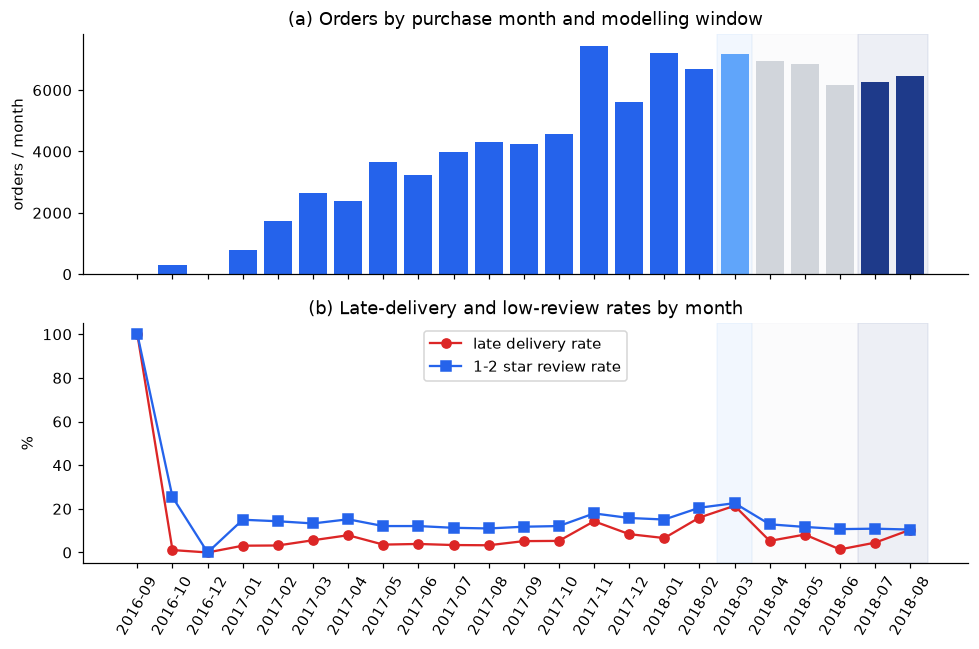

In [5]:
fig, ax = plt.subplots(2, 1, figsize=(9, 6), sharex=True)
x = np.arange(len(m))
colors = {"train": ACCENT, "validation": "#60a5fa", "maturation_gap": "#d1d5db", "test": "#1e3a8a", "excluded": GREY}
ax[0].bar(x, m.orders, color=[colors[w] for w in m.window])
ax[0].set_ylabel("orders / month"); ax[0].set_title("(a) Orders by purchase month and modelling window")
ax[1].plot(x, m.late_rate * 100, marker="o", color=RED, label="late delivery rate")
ax[1].plot(x, m.low_review_rate * 100, marker="s", color=ACCENT, label="1-2 star review rate")
ax[1].set_ylabel("%"); ax[1].set_title("(b) Late-delivery and low-review rates by month"); ax[1].legend()
ax[1].set_xticks(x); ax[1].set_xticklabels(m.index, rotation=60)
for a in ax:
    for w in ("validation", "maturation_gap", "test"):
        i = np.where(m.window == w)[0]
        a.axvspan(i.min() - 0.5, i.max() + 0.5, color=colors[w], alpha=0.08)
plt.tight_layout(); fig.savefig(config.FIGURES_DIR / "01_windows_and_rates.png", bbox_inches="tight")

## 3. Feature catalogue and missingness

Missing values are expected and meaningful for the delivery-as-of-T block (an order not delivered by its
promised date has no delivery duration yet). Every pipeline imputes with an indicator inside its own fit.

In [6]:
print(f"p2: {len(config.features_for('p2'))} features")
nan = p2[config.features_for("p2")].isna().mean().round(3)
nan[nan > 0].sort_values(ascending=False).to_frame("share missing (P2 cohort)")

p2: 49 features


,share missing (P2 cohort)
delivery_days_at_T,0.109
carrier_transit_days_at_T,0.109
days_vs_promise_at_T,0.109
delivery_vs_seller_prior_at_T,0.109
carrier_handover_days_at_T,0.017
main_category,0.016
max_distance_km,0.005


In [7]:
# the delivery-at-T block is where the Problem 2 signal lives
p2.groupby("delivered_by_T").is_low_review.agg(["mean", "size"]).rename(columns={"mean": "low-review rate", "size": "orders"})

,low-review rate,orders
delivered_by_T,,
0.0,0.598891,8479
1.0,0.092751,69606


## 4. Leakage audit

`features.assert_no_leakage` is structural (no post-outcome column can be a feature; the delivery-as-of-T block is
empty for orders not delivered by T). `features.leakage_audit` adds empirical checks: seller history recomputed
from scratch for a sample of orders (only outcomes known before purchase may contribute), internal consistency of the
delivery-as-of-T block, the share of reviews written before the survey trigger T, and the ranking power of every
feature on its own (a value near 1.0 would mean a feature encodes the label; `delivered_by_T` leading at about 0.77
is the delivery effect Phase 1 documented, not leakage).

In [8]:
features.assert_no_leakage(p2, "p2")
print("post-outcome columns (never features):", sorted(config.POST_OUTCOME_COLUMNS))
audit = features.leakage_audit(p2, "p2", sample=3000, full=df)
for k in ("history", "at_T", "review_time"):
    print(f"--- {k}"); print(audit[k].round(4).to_string())
audit["single_feature_auc"].to_csv(config.RESULTS_DIR / "single_feature_auc.csv", index=False)
display(audit["single_feature_auc"].head(12).round(3))
assert audit["history"]["only outcomes known before purchase"] == 1.0
assert audit["single_feature_auc"].roc_auc.max() < 0.9, "a single feature ranks the label almost perfectly: inspect it"
split.window_summary(p2, "p2").to_csv(config.RESULTS_DIR / "split_summary.csv")
split.fold_summary(split.split_frame(p2)["train"], "p2").to_csv(config.RESULTS_DIR / "fold_summary.csv")
import json
json.dump({"orders": int(len(df)), "p2_cohort": int(len(p2)), "windows": split.window_summary(p2, "p2").orders.to_dict(),
           "features": len(config.features_for("p2")), "leakage_audit_passed": True,
           "reviews_before_T_share": float(audit["review_time"]["reviews created before T"])},
          open(config.ROOT / "outputs" / "data_quality.json", "w"), indent=2)
print("OK - leakage audit passed")

post-outcome columns (never features): ['delivery_days', 'has_review_comment', 'is_low_review', 'is_on_time', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_status', 'review_answer_timestamp', 'review_creation_date', 'review_score', 'survey_trigger_time']
--- history
orders checked                         3000.0
seller_prior_orders exact match           1.0
only outcomes known before purchase       1.0
--- at_T
delivery_days_at_T is NaN when not delivered by T    1.0000
days_vs_promise_at_T <= 0 when delivered by T        1.0000
carrier_handover only when carrier date <= T         1.0000
delivered_by_T share                                 0.8914
--- review_time
reviews created before T        0.0290
median days from T to review    0.2836


,feature,roc_auc,pr_auc
0,delivered_by_T,0.772,0.495
1,customer_zip2,0.668,0.372
2,customer_state,0.640,0.330
3,seller_id_enc,0.625,0.341
4,route_prior_mean_delivery_days,0.620,0.308
5,route_prior_late_rate,0.609,0.320
6,total_freight,0.609,0.301
7,max_distance_km,0.594,0.289
8,same_state,0.588,0.263
9,promised_days,0.561,0.250


OK - leakage audit passed
